Matrix shape: (100, 100)
Matrix density: 2.28%
Column sums (should be ~1): 1.000000 to 1.000000

SPECTRAL DECOMPOSITION RESULTS

Leading eigenvalues:
  λ_0:  1.00000 +  0.00000i  (|λ| = 1.00000)
  λ_1: -0.29389 +  0.40451i  (|λ| = 0.50000)
  λ_2: -0.29389 + -0.40451i  (|λ| = 0.50000)
  λ_3:  0.29389 +  0.40451i  (|λ| = 0.50000)
  λ_4:  0.29389 + -0.40451i  (|λ| = 0.50000)
  λ_5:  0.47553 +  0.15451i  (|λ| = 0.50000)


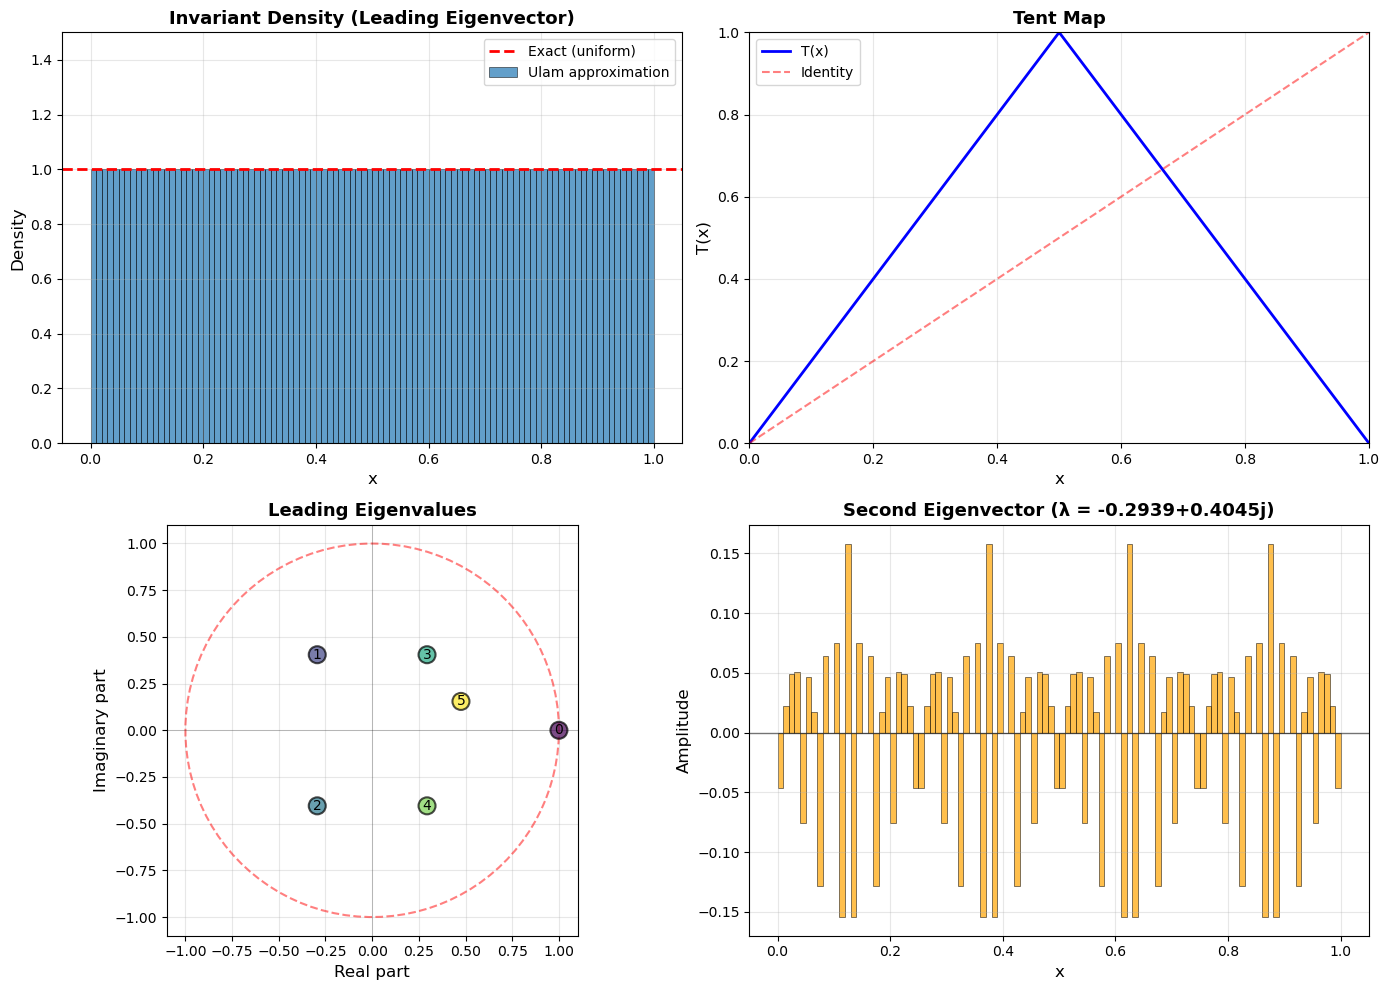


✓ Analysis complete! Figure saved as 'ulam_tent_map.png'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigs

def tent_map(x):
    """Tent map: T(x) = 2x for x≤0.5, T(x) = 2(1-x) for x>0.5"""
    return np.where(x <= 0.5, 2*x, 2*(1-x))

def ulam_tent_map(n_bins):
    """
    Ulam's method discretization for the tent map.
    Returns column-stochastic matrix P where P[j,i] = probability 
    that bin i maps into bin j.
    """
    bin_width = 1.0 / n_bins
    P = lil_matrix((n_bins, n_bins))
    
    for i in range(n_bins):
        # Source bin boundaries
        bin_left = i * bin_width
        bin_right = (i + 1) * bin_width
        
        if bin_right <= 0.5:
            # Entire bin in left branch: T(x) = 2x
            img_left = 2 * bin_left
            img_right = 2 * bin_right
            distribute_interval(P, i, img_left, img_right, 1.0, n_bins)
            
        elif bin_left >= 0.5:
            # Entire bin in right branch: T(x) = 2(1-x)
            img_left = 2 * (1 - bin_right)  # right edge maps to smaller value
            img_right = 2 * (1 - bin_left)
            distribute_interval(P, i, img_left, img_right, 1.0, n_bins)
            
        else:
            # Bin straddles x=0.5
            left_fraction = (0.5 - bin_left) / bin_width
            right_fraction = (bin_right - 0.5) / bin_width
            
            # Left part [bin_left, 0.5]
            distribute_interval(P, i, 2*bin_left, 1.0, left_fraction, n_bins)
            
            # Right part [0.5, bin_right]
            distribute_interval(P, i, 2*(1-bin_right), 1.0, right_fraction, n_bins)
    
    return P.tocsr()

def distribute_interval(P, source_bin, img_left, img_right, mass, n_bins):
    """Distribute mass from source bin across target bins based on image interval"""
    bin_width = 1.0 / n_bins
    
    # Find overlapping bins
    left_idx = int(np.floor(img_left * n_bins))
    right_idx = int(np.floor(img_right * n_bins))
    
    # Clamp to valid range
    left_idx = np.clip(left_idx, 0, n_bins - 1)
    right_idx = np.clip(right_idx, 0, n_bins - 1)
    
    if left_idx == right_idx:
        # Image entirely within one bin
        P[left_idx, source_bin] += mass
    else:
        # Image spans multiple bins
        img_width = img_right - img_left
        for j in range(left_idx, right_idx + 1):
            target_left = j * bin_width
            target_right = (j + 1) * bin_width
            
            # Compute overlap
            overlap_left = max(img_left, target_left)
            overlap_right = min(img_right, target_right)
            overlap = max(0, overlap_right - overlap_left)
            
            if overlap > 0:
                P[j, source_bin] += mass * (overlap / img_width)

# ============ MAIN EXAMPLE ============

# Discretize the operator
n_bins = 100
P = ulam_tent_map(n_bins)

print(f"Matrix shape: {P.shape}")
print(f"Matrix density: {P.nnz / (n_bins**2):.2%}")
print(f"Column sums (should be ~1): {P.sum(axis=0).min():.6f} to {P.sum(axis=0).max():.6f}")

# Compute leading eigenvalues and eigenvectors
# We need P^T for the Perron-Frobenius operator
k = 6
eigenvalues, eigenvectors = eigs(P.T, k=k, which='LM')

# Sort by magnitude
idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\n" + "="*50)
print("SPECTRAL DECOMPOSITION RESULTS")
print("="*50)
print("\nLeading eigenvalues:")
for i, lam in enumerate(eigenvalues):
    print(f"  λ_{i}: {lam.real:8.5f} + {lam.imag:8.5f}i  (|λ| = {np.abs(lam):.5f})")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Invariant density
invariant = np.real(eigenvectors[:, 0])
invariant = np.abs(invariant) / np.sum(np.abs(invariant)) * n_bins  # Normalize to density
x_centers = np.linspace(0.5/n_bins, 1-0.5/n_bins, n_bins)

axes[0, 0].bar(x_centers, invariant, width=1/n_bins, alpha=0.7, 
               edgecolor='black', linewidth=0.5, label='Ulam approximation')
axes[0, 0].axhline(y=1, color='r', linestyle='--', linewidth=2, label='Exact (uniform)')
axes[0, 0].set_xlabel('x', fontsize=12)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].set_title('Invariant Density (Leading Eigenvector)', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1.5])

# Plot 2: Tent map
x_plot = np.linspace(0, 1, 1000)
axes[0, 1].plot(x_plot, tent_map(x_plot), 'b-', linewidth=2, label='T(x)')
axes[0, 1].plot([0, 1], [0, 1], 'r--', alpha=0.5, linewidth=1.5, label='Identity')
axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel('T(x)', fontsize=12)
axes[0, 1].set_title('Tent Map', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 1])
axes[0, 1].set_ylim([0, 1])

# Plot 3: Eigenvalue spectrum
axes[1, 0].scatter(np.real(eigenvalues), np.imag(eigenvalues), 
                   s=150, alpha=0.7, c=range(k), cmap='viridis', 
                   edgecolors='black', linewidth=1.5, zorder=3)
for i, (re, im) in enumerate(zip(np.real(eigenvalues), np.imag(eigenvalues))):
    axes[1, 0].annotate(f'{i}', (re, im), fontsize=10, ha='center', va='center')

# Unit circle
theta = np.linspace(0, 2*np.pi, 100)
axes[1, 0].plot(np.cos(theta), np.sin(theta), 'r--', alpha=0.5, linewidth=1.5)
axes[1, 0].axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
axes[1, 0].set_xlabel('Real part', fontsize=12)
axes[1, 0].set_ylabel('Imaginary part', fontsize=12)
axes[1, 0].set_title('Leading Eigenvalues', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_aspect('equal')

# Plot 4: Second eigenvector
if k > 1:
    second = np.real(eigenvectors[:, 1])
    axes[1, 1].bar(x_centers, second, width=1/n_bins, alpha=0.7, 
                   edgecolor='black', linewidth=0.5, color='orange')
    axes[1, 1].axhline(y=0, color='k', linewidth=1, alpha=0.5)
    axes[1, 1].set_xlabel('x', fontsize=12)
    axes[1, 1].set_ylabel('Amplitude', fontsize=12)
    axes[1, 1].set_title(f'Second Eigenvector (λ = {eigenvalues[1]:.4f})', 
                        fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ulam_tent_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Analysis complete! Figure saved as 'ulam_tent_map.png'")

This aligns with known Ulam-Neumann results connecting the tent map's transfer operator to Chebyshev polynomials.

